<br/>
<img src="images/skillnest-logo.png" alt="" width="200px" align="left"/>
<img src="images/skillnest-logo.png" alt="" width="200px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science - Módulo 4</h2><br/>
<h1>IA Generativa</h1>
<br/><br/>
    <b>Instructor Principal:</b> Patricio Olivares polivares@skillnest.com <br/>
    <b>Instructor Asistente:</b> Cristian Sánchez csanchez@skillnest.com<br/><br/>
    <b>Skill Nest</b>
</div>
<br>

## 1. Introducción a la IA Generativa

- La inteligencia artificial generativa se enfoca en crear contenido nuevo a partir de patrones aprendidos en datos existentes.
- A diferencia de modelos tradicionales que solo clasifican o predicen, los modelos generativos pueden producir texto, imágenes, sonidos o incluso código.
- Una analogía útil es pensar en un chef que ha probado miles de recetas. No memoriza todas, pero entiende combinaciones de ingredientes y técnicas. Con esa experiencia, puede inventar una receta nueva que no ha visto antes. Los modelos generativos operan de forma similar: aprenden distribuciones y relaciones en los datos y luego generan nuevas muestras compatibles.
- Esta tecnología permite, por ejemplo, que una máquina escriba una historia original, pinte una imagen basada en una descripción o genere música con un estilo determinado.

### Ejemplos de uso actuales

- Generación de textos automatizados para correos, resúmenes o guiones.
- Creación de imágenes sintéticas en diseño, publicidad y videojuegos.
- Asistentes conversacionales capaces de mantener diálogos naturales.
- Generación de código para automatizar tareas de programación.
- Producción de voces sintéticas para doblaje o accesibilidad.
- Reconstrucción de escenas visuales o restauración de contenido dañado.

### Desafíos éticos y morales

- Aunque el potencial de esta tecnología es amplio, aún existen debates importantes en torno a su uso responsable.
- Entre los desafíos más discutidos se encuentran el uso de contenido generado para desinformación, la atribución de propiedad intelectual, la generación de sesgos o estereotipos, y el reemplazo de trabajos humanos en áreas creativas.
- El desarrollo y aplicación de la IA generativa requiere no solo innovación técnica, sino también marcos éticos y regulaciones claras que acompañen su despliegue.



## 2. Generación de texto con modelos de lenguaje

- Uno de los campos más desarrollados en la IA generativa es la generación de texto, impulsada por modelos de lenguaje entrenados sobre grandes volúmenes de datos.
- Estos modelos, como GPT (Generative Pretrained Transformer, autoregresivo), T5 (Text-to-Text Transfer Transformer, encoder-decoder) o BART (Bidirectional and Auto-Regressive Transformers, encoder-decoder híbrido), son capaces de redactar desde simples oraciones hasta textos completos como correos, resúmenes, poemas o incluso artículos técnicos.
- A diferencia de modelos como BERT, que están enfocados en tareas de comprensión, los modelos generativos predicen la siguiente palabra en una secuencia, una tras otra, en lo que se conoce como generación autoregresiva.
- Esta generación puede controlarse mediante un texto inicial o *prompt*, que define el tema o tono del contenido generado.

### Ejemplos de tareas típicas

- Completar una oración o párrafo.
- Generar respuestas a preguntas abiertas.
- Redactar contenido basado en instrucciones.
- Reescribir textos en otro estilo o nivel de formalidad.
- Traducir, resumir o expandir contenido.

### Parámetros clave que afectan la generación

- `max_length`: número máximo de tokens en la respuesta generada.
- `temperature`: controla la aleatoriedad de la salida (valores bajos generan texto más predecible, valores altos más variado).
- `top_k` y `top_p`: técnicas de muestreo para limitar el espacio de palabras posibles y controlar la creatividad del modelo.

### Limitaciones a considerar

- El modelo no "comprende" el texto como un humano, sino que predice palabras según patrones estadísticos.
- Puede generar contenido plausible pero incorrecto o inventado.
- Su comportamiento depende del entrenamiento: si los datos son sesgados, los resultados también pueden serlo.


In [ ]:
from transformers import pipeline

# Crear un generador de texto con GPT-2
generator = pipeline("text-generation", model="gpt2")

# Prompt de entrada
prompt = "Artificial intelligence is changing the way we"

# Generar texto
result = generator(
    prompt,
    max_new_tokens=5,         # número máximo de tokens nuevos en la secuencia generada (no incluye el prompt)
    num_return_sequences=1 # cantidad de resultados distintos que se desean obtener
)


# Mostrar resultado
print(result[0]["generated_text"])


Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Artificial intelligence is changing the way we think about the world.


### Ejemplo de uso práctico

- En este ejemplo se utiliza el modelo `gpt2` para generar texto a partir del prompt "Artificial intelligence is changing the way we".
- El parámetro `max_new_tokens=5` indica que se generarán como máximo cinco tokens nuevos después del prompt original. Esto permite un control más preciso sobre la longitud de la generación.
- `num_return_sequences=1` indica que se desea obtener una sola respuesta generada.
- A diferencia de `max_length`, que define la longitud total de la secuencia (prompt + salida), `max_new_tokens` considera únicamente la parte generada.
- Este parámetro es útil para evitar que el modelo genere respuestas demasiado largas o fuera de contexto.
- El resultado puede variar en cada ejecución debido al uso de muestreo estocástico en la predicción de palabras.


## 3. Prompt Engineering y el contexto

- El rendimiento de un modelo generativo depende en gran medida de cómo se formula el prompt.
- Prompt engineering es la práctica de diseñar instrucciones claras, específicas y estratégicas para guiar al modelo en la tarea deseada.
- El modelo no tiene intención ni comprensión del lenguaje, por lo que detalles como el tono, el formato esperado o la inclusión de ejemplos pueden marcar una gran diferencia.

### ¿Qué es un prompt?

- Un prompt es el texto de entrada que se entrega al modelo para que genere una continuación.
- Puede ser una pregunta, una instrucción, una frase incompleta o incluso un bloque de texto con ejemplos.

### Tipos de estrategias comunes

- **Zero-shot**: se entrega solo la instrucción, sin ejemplos.
  - Ejemplo: "Translate this sentence to French: I love programming."
- **One-shot**: se entrega un ejemplo junto con la instrucción.
  - Ejemplo: "English: Hello — Spanish: Hola. English: Thank you — Spanish:"
- **Few-shot**: se entregan varios ejemplos para ilustrar el patrón deseado.
  - Ejemplo: "English: Cat — Spanish: Gato. English: Dog — Spanish: Perro. English: House — Spanish:"

### Consideraciones clave

- El modelo solo tiene acceso al texto entregado en el prompt y no conserva memoria entre llamados.
- La calidad del resultado mejora cuando el contexto del prompt es claro, coherente y proporciona señales del formato de salida esperado.
- A veces pequeñas variaciones en la redacción pueden alterar significativamente la respuesta generada.

### Ejemplos prácticos con distintos modelos

In [5]:
from transformers import pipeline

# Requiere librería tokenizer sentencepiece (pip install sentencepiece)
# Zero-shot
# Pipeline de traducción inglés-español
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-en-es")

# Texto a traducir
text = "I love programming."

# Traducción
translated = translator(text, max_length=40)
print("Traducción:")
print(translated[0]["translation_text"])


Device set to use cuda:0


Traducción:
Me encanta la programación.


In [ ]:
from transformers import pipeline

generator = pipeline("text2text-generation", model="google/flan-t5-base")

# One-shot prompting
prompt = (
    "Translate the following English sentences to Spanish.\n"
    "English: Hello - Spanish: Hola.\n"
    "English: Thank you - Spanish:"
)

# Generar la traducción
output = generator(prompt)

# Mostrar resultado
print("One-shot (FLAN-T5):")
print(output[0]['generated_text'])


Device set to use cuda:0


One-shot (FLAN-T5):
Gracias.


In [1]:
from transformers import pipeline

generator = pipeline("text-generation", model="EleutherAI/gpt-neo-1.3B")

prompt = (
    "English: Cat → Spanish: Gato.\n"
    "English: Dog → Spanish: Perro.\n"
    "English: House → Spanish: Casa.\n"
    "English: Book"
)

print("Prompt:\n", prompt)
output = generator(prompt, max_new_tokens=5, do_sample=False)
print("\nOutput:\n", output[0]["generated_text"])



2025-07-22 02:24:11.587763: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-22 02:24:11.600612: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753165451.617677   36694 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753165451.622632   36694 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753165451.635446   36694 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Prompt:
 English: Cat → Spanish: Gato.
English: Dog → Spanish: Perro.
English: House → Spanish: Casa.
English: Book

Output:
 English: Cat → Spanish: Gato.
English: Dog → Spanish: Perro.
English: House → Spanish: Casa.
English: Book → Spanish: Libro


## 4. Ejemplo: Usando un modelo para rellenar un párrafo

- En este ejemplo observaremos cómo un modelo generativo puede continuar un fragmento de texto a partir de un inicio narrativo.
- La idea es entregar al modelo el comienzo de una historia, como si le diéramos una hoja escrita a medias, y permitirle completarla a su manera.
- Analizaremos el resultado generado y cómo este puede variar con pequeños cambios en el prompt o en los parámetros de generación..


In [13]:
from transformers import pipeline

# Usamos GPT-2 para generar texto
generator = pipeline("text-generation", model="gpt2")

# Prompt narrativo inicial
prompt = (
    "The sun had already disappeared behind the mountains. She opened the old notebook and read:\n"
    "\"If you're reading this, it means you found the first clue. The next step is"
)

# Generación del texto
output = generator(
    prompt,
    max_new_tokens=60,
    temperature=0.9,
    top_k=50,
    top_p=0.95,
    num_return_sequences=1
)

print("Texto generado:\n")
print(output[0]["generated_text"])


Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Texto generado:

The sun had already disappeared behind the mountains. She opened the old notebook and read:
"If you're reading this, it means you found the first clue. The next step is to find the "last clue". Your mission is to prove the others wrong. Your mission is not to try to find the last clue or to find the rest. The way you find the clues to your mission, you will be able to accomplish your goal, but you will not be able to accomplish


### Explicación de los parámetros del generador

- `prompt`: es el texto de entrada que inicia la generación. El modelo lo toma como contexto y lo continúa palabra por palabra.
- `max_new_tokens=60`: limita la cantidad de tokens que el modelo puede generar más allá del prompt original. No incluye los tokens del prompt.
- `temperature=0.9`: controla el nivel de aleatoriedad en la generación. Valores bajos (por ejemplo, 0.2) hacen que el modelo sea más conservador y repetitivo. Valores altos (como 0.9) introducen más creatividad y variedad.
- `top_k=50`: restringe la selección de la siguiente palabra a las 50 opciones más probables. Esto limita el espacio de búsqueda y puede mejorar la coherencia.
- `top_p=0.95`: activa el muestreo por núcleo (*nucleus sampling*), que considera solo el conjunto más pequeño de palabras cuya probabilidad acumulada alcanza el 95%. Es una forma alternativa de controlar la aleatoriedad.
- `num_return_sequences=1`: indica que solo se quiere una única secuencia generada. Si se aumenta este valor, se obtendrán varias alternativas distintas para el mismo prompt.

Estos parámetros permiten encontrar un equilibrio entre coherencia, creatividad y control sobre la longitud de la salida generada.

## 5. Introducción a la Generación de Imágenes

- La generación de imágenes mediante inteligencia artificial busca crear imágenes sintéticas a partir de datos aprendidos, texto o ruido aleatorio.
- A diferencia de los modelos de lenguaje, donde la unidad de salida es un token de texto, los modelos generativos de imágenes producen pixeles, vectores latentes o matrices intermedias que son decodificadas visualmente.

### Principales enfoques

- **GANs (Generative Adversarial Networks)**: entrenan dos redes, un generador y un discriminador, que compiten entre sí. El generador intenta crear imágenes realistas, mientras que el discriminador intenta distinguir entre imágenes reales y falsas.
- **VAEs (Variational Autoencoders)**: codifican datos en un espacio latente y los decodifican para generar nuevas muestras similares.
- **Modelos de difusión**: comienzan con ruido puro y aprenden a invertir el proceso para generar imágenes claras. Se han vuelto populares por su calidad y control.

### Aplicaciones actuales

- Creación de imágenes a partir de descripciones textuales.
- Generación de retratos artificiales, paisajes, arte y estilos específicos.
- Diseño de productos, moda y arquitectura.
- Restauración y edición de imágenes dañadas o incompletas.
- Simulación de datos para entrenamiento de modelos supervisados.

### Diferencias clave frente a la generación de texto

- Las imágenes tienen una estructura espacial (alto, ancho, canales) que hace más costosa su representación y procesamiento.
- El control sobre la generación visual puede lograrse con etiquetas, ruido latente o texto como entrada.
- Mientras los modelos de texto generan en secuencia, los modelos de imagen suelen operar sobre toda la representación de forma más global.

## 6. Ejemplo de generación simple: del ruido a la imagen

Este ejemplo muestra cómo un generador simple puede transformar ruido aleatorio en imágenes estilo MNIST, sin necesidad de un discriminador ni entrenamiento adversarial.

- Se utiliza un modelo en Keras que combina capas densas y `Conv2DTranspose` para generar imágenes de forma `(28, 28, 1)`.
- Los pesos son aleatorios y no se optimizan: el objetivo es observar cómo una red puede producir patrones visuales a partir de ruido.
- Sirve como antesala a las GANs, ilustrando el rol del generador y la necesidad posterior de entrenamiento guiado.
- Introduce el concepto de espacio latente (`z`) como entrada clave en modelos generativos.

/home/polivares/.local/share/mamba/envs/DataScience/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


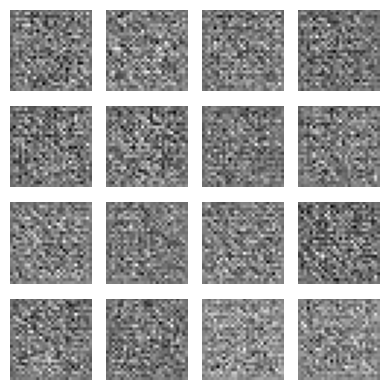

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Dimensión del vector de ruido (espacio latente)
z_dim = 100

# Modelo generador
def build_generator():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7 * 7 * 128, input_shape=(z_dim,)))
    model.add(layers.Reshape((7, 7, 128)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Capa final que genera una imagen de 28x28 con 1 canal (escala de grises),
    # aplicando sigmoid a cada pixel para obtener valores entre 0 y 1
    model.add(layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding='same', activation='sigmoid'))
    return model

# Crear el generador
generator = build_generator()

# Generar un batch de vectores de ruido
num_images = 16
noise = tf.random.normal([num_images, z_dim])

# Generar imágenes
generated_images = generator(noise, training=False)

# Visualizar las imágenes generadas
plt.figure(figsize=(4, 4))
for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i, :, :, 0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()


## Entrenando una GAN completa con imágenes MNIST

En este ejemplo combinamos un generador y un discriminador para construir una GAN funcional. El generador transforma ruido en imágenes estilo MNIST, mientras que el discriminador intenta distinguir entre imágenes reales y generadas.

- El generador es el mismo modelo usado previamente: transforma un vector de ruido en una imagen `28x28x1` mediante `Dense` y `Conv2DTranspose`.
- El discriminador es una red convolucional que clasifica imágenes como reales o falsas.
- Ambos modelos se entrenan de manera alternada: el discriminador aprende a distinguir, y el generador aprende a engañar.
- Al finalizar cada época, se visualizan ejemplos generados para observar el progreso.

Este ejercicio muestra el principio del entrenamiento adversarial, núcleo de las GANs.


Época 0 completada


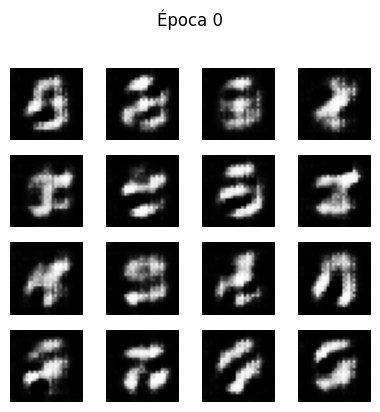

Época 1 completada
Época 2 completada
Época 3 completada
Época 4 completada
Época 5 completada
Época 6 completada
Época 7 completada
Época 8 completada
Época 9 completada
Época 10 completada


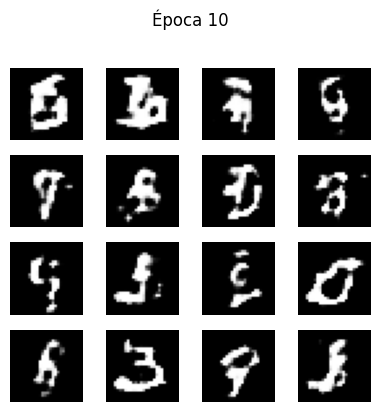

Época 11 completada
Época 12 completada
Época 13 completada
Época 14 completada
Época 15 completada
Época 16 completada
Época 17 completada
Época 18 completada
Época 19 completada
Época 20 completada


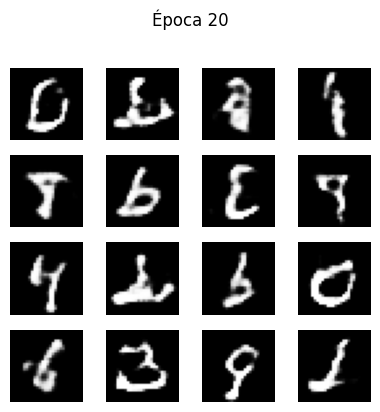

Época 21 completada
Época 22 completada
Época 23 completada
Época 24 completada
Época 25 completada
Época 26 completada
Época 27 completada
Época 28 completada
Época 29 completada
Época 30 completada


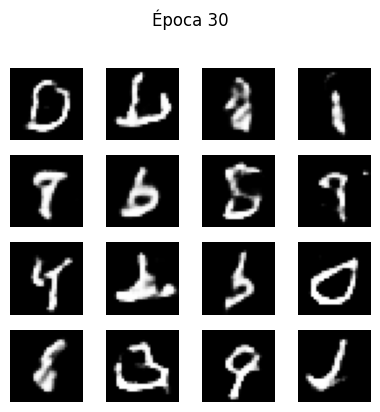

Época 31 completada
Época 32 completada
Época 33 completada
Época 34 completada
Época 35 completada
Época 36 completada
Época 37 completada
Época 38 completada
Época 39 completada
Época 40 completada


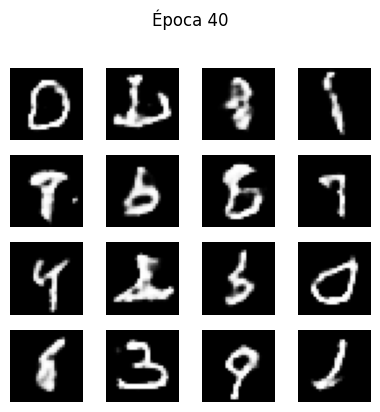

Época 41 completada
Época 42 completada
Época 43 completada
Época 44 completada
Época 45 completada
Época 46 completada
Época 47 completada
Época 48 completada
Época 49 completada
Época 50 completada


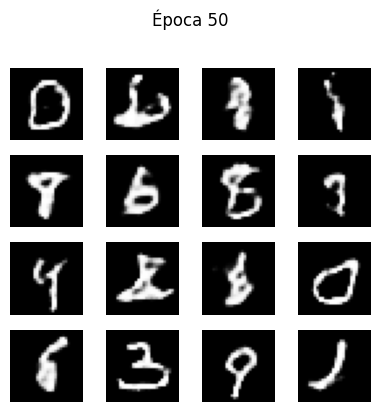

Época 51 completada
Época 52 completada
Época 53 completada
Época 54 completada
Época 55 completada
Época 56 completada
Época 57 completada
Época 58 completada
Época 59 completada
Época 60 completada


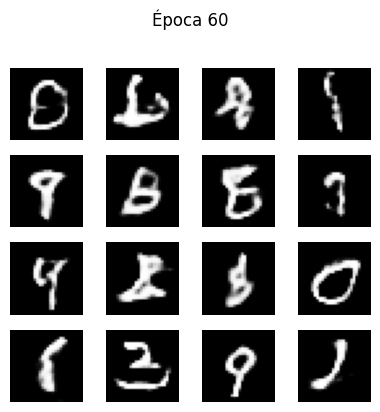

Época 61 completada
Época 62 completada
Época 63 completada
Época 64 completada
Época 65 completada
Época 66 completada
Época 67 completada
Época 68 completada
Época 69 completada
Época 70 completada


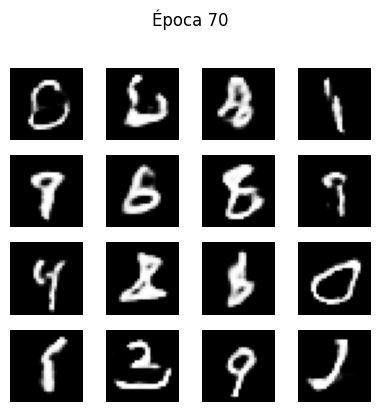

Época 71 completada
Época 72 completada
Época 73 completada
Época 74 completada
Época 75 completada
Época 76 completada
Época 77 completada
Época 78 completada
Época 79 completada
Época 80 completada


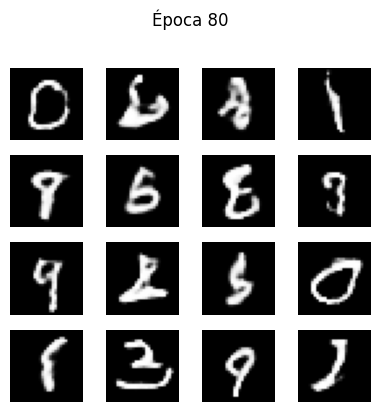

Época 81 completada
Época 82 completada
Época 83 completada
Época 84 completada
Época 85 completada
Época 86 completada
Época 87 completada
Época 88 completada
Época 89 completada
Época 90 completada


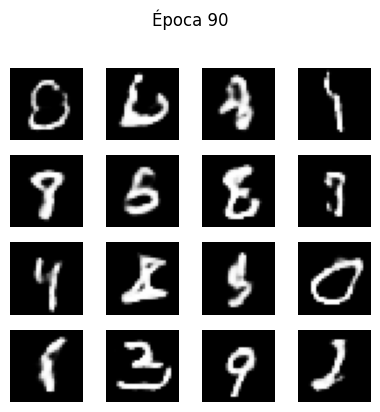

Época 91 completada
Época 92 completada
Época 93 completada
Época 94 completada
Época 95 completada
Época 96 completada
Época 97 completada
Época 98 completada
Época 99 completada


In [12]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
z_dim = 100               # Dimensión del vector de ruido de entrada
BUFFER_SIZE = 60000       # Cantidad total de imágenes en MNIST
BATCH_SIZE = 128          # Tamaño del batch
EPOCHS = 100              # Número total de épocas de entrenamiento

# --- Generador ---
def build_generator():
    model = tf.keras.Sequential()
    # Proyecta el vector de ruido a un volumen 7x7x128
    model.add(layers.Dense(7 * 7 * 128, input_shape=(z_dim,)))
    model.add(layers.Reshape((7, 7, 128)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsampling: 7x7x128 -> 14x14x64
    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsampling final: 14x14x64 -> 28x28x1
    # Usa sigmoid para generar valores entre 0 y 1 (escala de grises)
    model.add(layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding='same', activation='sigmoid'))
    return model

generator = build_generator()

# --- Discriminador ---
def build_discriminator():
    model = tf.keras.Sequential()
    # Conv2D: reduce tamaño espacial y extrae patrones
    model.add(layers.Conv2D(64, (5, 5), strides=2, padding='same', input_shape=(28, 28, 1)))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Segunda capa convolucional
    model.add(layers.Conv2D(128, (5, 5), strides=2, padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Aplanamiento y salida binaria (probabilidad real/falsa)
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

discriminator = build_discriminator()

# --- Pérdidas y optimizadores ---
cross_entropy = tf.keras.losses.BinaryCrossentropy()

# Función de pérdida del discriminador (real vs falsa)
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)   # reales deben clasificarse como 1
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)  # falsas deben clasificarse como 0
    return real_loss + fake_loss

# Función de pérdida del generador (quiere engañar al discriminador)
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)  # idealmente, el D(iscriminador) dice que lo falso es real

# Optimizadores independientes
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# --- Dataset MNIST ---
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
# Normalizar a [0, 1] y añadir canal de profundidad
train_images = (train_images.astype('float32') / 255.0).reshape(-1, 28, 28, 1)
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# --- Entrenamiento por pasos ---
# Esta función representa un solo paso de entrenamiento de la GAN.
# Se entrena el generador y el discriminador usando un batch del dataset.
@tf.function  # Optimiza la función compilándola como un grafo computacional (mejora rendimiento)
def train_step(images, generator, discriminator):
    # 1. Se genera un batch de vectores de ruido (uno por imagen real del batch)
    noise = tf.random.normal([BATCH_SIZE, z_dim])

    # 2. Se definen dos "cintas" de gradientes para grabar las operaciones de cada red por separado
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 3. El generador produce imágenes falsas a partir del ruido
        generated_images = generator(noise, training=True)

        # 4. El discriminador evalúa tanto imágenes reales como generadas
        real_output = discriminator(images, training=True)              # Salida para imágenes reales
        fake_output = discriminator(generated_images, training=True)    # Salida para imágenes falsas

        # 5. Se calcula la pérdida del generador (quiere que el D diga que sus imágenes son reales)
        gen_loss = generator_loss(fake_output)

        # 6. Se calcula la pérdida del discriminador (quiere distinguir reales vs falsas correctamente)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 7. Se obtienen los gradientes del generador respecto a su pérdida
    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    # 8. Se aplica el optimizador para actualizar los pesos del generador
    generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))

    # 9. Se obtienen los gradientes del discriminador respecto a su pérdida
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    # 10. Se aplica el optimizador para actualizar los pesos del discriminador
    discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    # Se retorna la pérdida de ambas redes (opcional, útil para monitoreo)
    return gen_loss, disc_loss


# --- Visualización de imágenes generadas ---
def generate_and_plot_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Época {epoch}", y=1.02)
    plt.tight_layout()
    plt.show()

# --- Entrenamiento completo ---
def train(generator, discriminator, dataset, epochs):
    seed = tf.random.normal([16, z_dim])  # Semilla para imágenes consistentes en cada visualización
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch, generator, discriminator)
        print(f"Época {epoch} completada")
        if epoch % 10 == 0:
            generate_and_plot_images(generator, epoch, seed)

# Ejecutar entrenamiento
train(generator, discriminator, train_dataset, EPOCHS)



### ¿Qué hace este código?

Este código implementa una GAN simple para generar imágenes de dígitos manuscritos estilo MNIST desde ruido aleatorio.

- **Generador:** toma vectores de ruido de dimensión 100 y los transforma en imágenes de 28x28x1. Usa `Conv2DTranspose` para aumentar resolución.
- **Discriminador:** es una red convolucional que recibe una imagen y predice si es real o generada.
- **Entrenamiento adversarial:** el generador intenta engañar al discriminador y este intenta detectar imágenes falsas. Ambas redes se entrenan alternadamente.
- **Visualización:** cada 10 épocas se muestran 16 imágenes generadas a partir de una semilla fija de ruido.

Este ejercicio permite observar cómo una red puede aprender a generar dígitos realistas sin haber visto ejemplos explícitos de cada uno. Con suficiente entrenamiento, el generador produce imágenes que visualmente parecen pertenecer al dataset MNIST.

### Uso de una GAN pre-entrenada

- Se carga una **GAN preentrenada** directamente desde Hugging Face mediante `from_pretrained_keras`.
- El modelo corresponde a una **Deep Convolutional GAN (DCGAN)**, una arquitectura clásica de generación de imágenes.
- Está entrenado para generar imágenes del estilo **CryptoPunks**, una colección de retratos pixelados de personajes generados algorítmicamente.
- Solo se necesita generar un vector de ruido y pasarlo por el generador para obtener nuevas imágenes.

Detalles del proceso:

- Se utiliza el modelo `huggan/crypto-gan`, disponible en Hugging Face, especialmente entrenado para generar imágenes estilizadas de tipo CryptoPunks.
- Con `from_pretrained_keras`, obtenemos directamente un generador compatible con TensorFlow/Keras.
- Se crea un batch de ruido (`shape = (N_IMAGES, Z_DIM)`) y se pasa al generador para obtener imágenes.
- Finalmente, se visualiza el resultado: un conjunto de imágenes generadas sin entrenar nada adicional.
- Este enfoque permite entender rápidamente cómo funciona una GAN en producción y sirve como demostración destacable del potencial de modelos generativos ya entrenados disponibles en la nube.


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

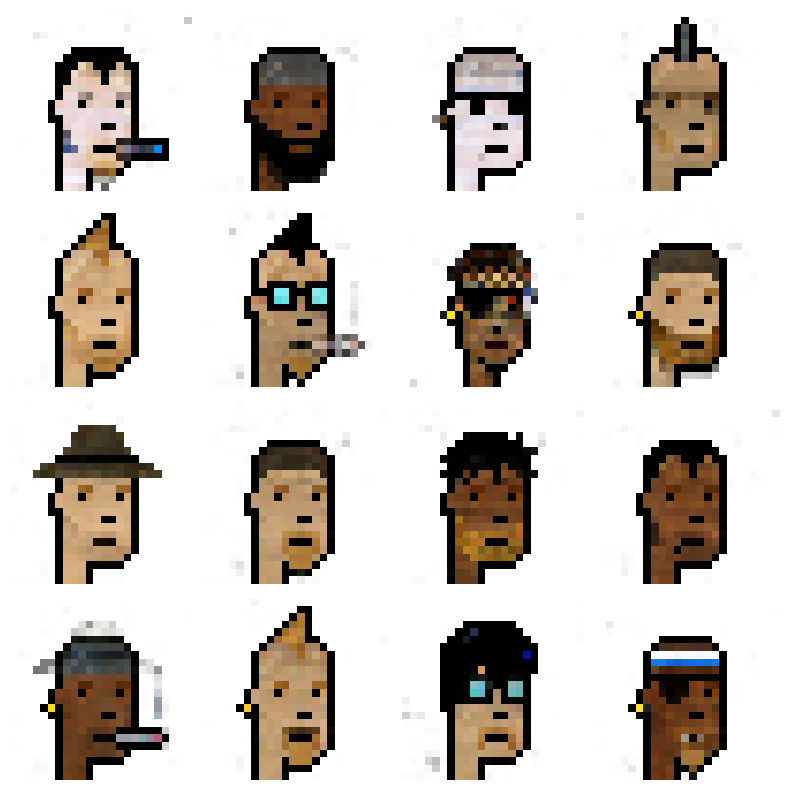

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
from huggingface_hub import from_pretrained_keras

# Parámetros
MODEL_ID = "huggan/crypto-gan"
Z_DIM = 100       # Dimensión del vector de ruido
N_IMAGES = 16     # Número de imágenes a generar

# Descargar el generador pre-entrenado desde Hugging Face
generator = from_pretrained_keras(MODEL_ID)

# Generar ruido y producir imágenes
noise = tf.random.normal(shape=(N_IMAGES, Z_DIM), seed=42)
generated_images = generator(noise, training=False)

# Mostrar las imágenes generadas
plt.figure(figsize=(8, 8))
for i in range(N_IMAGES):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i, :, :, :])
    plt.axis("off")
plt.tight_layout()
plt.show()



## 7. Modelos de Difusión

Los modelos de difusión son una de las técnicas más recientes y poderosas en el campo de la generación de imágenes. Han demostrado resultados sobresalientes en tareas como generación de retratos realistas, arte conceptual y restauración de imágenes.

### ¿Cómo funcionan?

- Estos modelos se inspiran en procesos físicos de difusión inversa.
- La idea central es **aprender a invertir un proceso de degradación progresiva**, donde una imagen se convierte en ruido paso a paso.
- Durante el entrenamiento, el modelo aprende a recuperar la imagen original a partir de versiones con distintos niveles de ruido.

### Fases del proceso

1. **Forward process (difusión):** se toma una imagen y se le añade ruido en múltiples pasos hasta que se vuelve indistinguible del ruido puro.
2. **Reverse process (generación):** el modelo aprende a invertir este proceso, eliminando ruido paso a paso hasta reconstruir una imagen coherente.

### Características clave

- El modelo genera imágenes desde ruido puro, sin necesidad de vector latente o semilla explícita.
- Se requiere una cadena de pasos de inferencia (decenas o cientos), por lo que es más lento que una GAN.
- Ofrece un control más fino y estable sobre el resultado generado.

### Ventajas frente a GANs

- Menos propenso a colapso de modo (produce más variedad).
- Mejor calidad visual en tareas como generación de rostros y paisajes.
- Más fácil de condicionar con texto, etiquetas u otras imágenes.

### Ejemplos populares

- **DALL·E 2** y **Imagen** (de Google) usan variantes de modelos de difusión.
- **Stable Diffusion** es un modelo de código abierto ampliamente usado para generar imágenes a partir de texto.
- **DDPM (Denoising Diffusion Probabilistic Models)** es la formulación base de muchos modelos de difusión actuales.

### Aplicaciones

- Generación de arte visual y diseño gráfico.
- Creación de imágenes realistas a partir de texto (text-to-image).
- Restauración de imágenes dañadas o pixeladas.
- Superresolución (aumento de calidad de imágenes).



### ¿Cómo el texto guía la generación de imágenes en modelos de difusión?

En modelos como Stable Diffusion, el texto (prompt) se usa para guiar el proceso de generación mediante un mecanismo de condición:

- El prompt es convertido en un vector semántico usando un modelo de lenguaje (como CLIP o T5).
- Ese vector guía el proceso de denoising paso a paso, orientando la imagen hacia lo que describe el texto.
- Este enfoque se llama **difusión condicional**.

Además:

- Stable Diffusion genera imágenes en un **espacio latente comprimido**, no directamente en píxeles.
- Al finalizar, ese espacio latente se decodifica en una imagen visible con un autoencoder.

Este proceso permite generar imágenes coherentes con el texto y de alta calidad, usando menos recursos.

### Ejemplo práctico: uso de Stable Diffusion con TensorFlow/Keras

Este ejemplo carga una implementación preentrenada de **Stable Diffusion** disponible en KerasCV, genera imágenes a partir de un prompt y muestra cómo utilizarla de forma sencilla.

### ¿Qué es KerasCV?

KerasCV es una biblioteca de código abierto desarrollada por el equipo de Keras que proporciona implementaciones listas para usar de modelos y herramientas para tareas de visión por computador.

- Está basada en TensorFlow y se integra directamente con la API de Keras.
- Incluye modelos preentrenados para clasificación, detección de objetos, segmentación y generación de imágenes.
- Soporta tareas modernas como Stable Diffusion, superresolución, data augmentation avanzado y pipelines de entrenamiento.

KerasCV permite experimentar con modelos de visión de forma rápida y reproducible, sin tener que implementar arquitecturas complejas desde cero.


By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 309ms/step


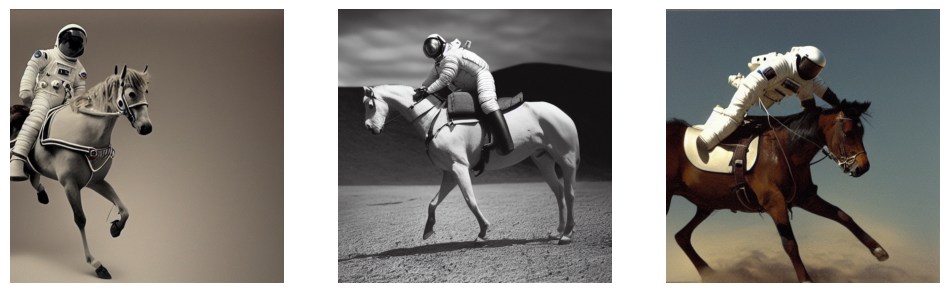

In [4]:
# Instala si no lo tienes: pip install tensorflow keras_cv
import tensorflow as tf
import keras_cv
import matplotlib.pyplot as plt

# ---- Selección de GPUs, comentar si se cuenta con una sola 
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')  # GPU 0
        tf.config.experimental.set_memory_growth(gpus[1], True)
    except RuntimeError as e:
        print(e)
# ---- Cierre de selección de GPU

# Carga el modelo de Stable Diffusion
model = keras_cv.models.StableDiffusion(img_width=512, img_height=512)

# Prompt y generación
prompt = "a photograph of an astronaut riding a horse"

images = model.text_to_image(prompt, batch_size=3)

# Función para mostrar las imágenes en grilla
def plot_images(imgs):
    plt.figure(figsize=(12, 4))
    for i, img in enumerate(imgs):
        ax = plt.subplot(1, len(imgs), i + 1)
        plt.imshow(img)
        plt.axis("off")

plot_images(images)


### Explicación del ejemplo

- Se utiliza `keras_cv.models.StableDiffusion`, una implementación en TensorFlow/Keras del modelo **Latent Diffusion** basado en Stable Diffusion .
- El modelo recibe un *prompt* de texto y genera imágenes de tamaño 512×512.
- La inferencia es posible con una sola línea: `model.text_to_image(prompt)`.
- Este enfoque permite a los estudiantes interactuar de forma inmediata con un modelo de difusión de vanguardia, sin necesidad de instalar PyTorch o manejar pipelines complejos.
